# Mini-Projeto 01. Análise de Vendas

In [2]:
!pip install -q -U watermark

In [3]:
#Importar bibliotecas pandas para manipulação de dados em tabelas
import pandas as pd

#Importar biblioteca NumPy para operações matemáticas e arrays
import numpy as np

#Importar biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt

#Importar biblioteca seaborn para visualizar estatísticas de dados
import seaborn as sns

#Importar random para gerar números aleatórios
import random

#Importar classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta

# Comando do jupyter que serve para exibir gráficos diretamente no notebook
%matplotlib inline

In [4]:
%reload_ext watermark
%watermark -a "Emanoel"

Author: Emanoel



In [5]:
%watermark --iversion

numpy     : 2.1.3
matplotlib: 3.10.0
seaborn   : 0.13.2
pandas    : 2.2.3



In [6]:
#Para fazer a instalação específica de uma biblioteca fazer o seguinte comando:
#!pip install -q pandas == 2.3.1

# 3. Função Para Geração de Dados Fictícios
Excelente forma de praticar muito do que vimos até aqui neste capítulo.



In [7]:
def Gerador_de_dados(num_registro = 600):

    print(f"\nIniciando a geração de {num_registro} registro de vendas")

    Products = {
        'Laptop Gamer' : {'categoria' : 'Eletrônicos', 'preco' : 7500.00},
        'Mouse Vertical' : {'categoria' : 'Acessório', 'preco' : 250.00},
        'Teclado Mecânico' : {'categoria' : 'Acessório', 'preco' : 550.00},
        'Monitor Ultrawide' : {'categoria' : 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer' : {'categoria' : 'Móveis', 'preco' : 1200.00},
        'Headset 7.1' : {'categoria' : 'Acessório', 'preco' : 800.00},
        'Placa de Vídeo' : {'categoria' : 'Hardware', 'preco' : 4500.00},
        'SSD 1TB' : {'categoria' : 'Hardware', 'preco' : 600.00},
    }

    list_products = list(Products.keys())

    cidade_estado = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    list_cidade = list(cidade_estado.keys())

    dados_vendas = []

    data_inicial = datetime(2026, 1, 1)

    for i in range(num_registro):

        Products_random = random.choice(list_products)

        cidade_random = random.choice(list_cidade)

        quantidade = np.random.randint(1, 8)
        datas_pedidos = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        if Products_random in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = Products[Products_random]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = Products[Products_random]['preco']

        dados_vendas.append({

            'ID_pedido' : 1000 + i,
            'Data_pedido' : datas_pedidos,
            'Nome_Produto': Products_random,
            'Categoria': Products[Products_random]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade_random,
            'Estado': cidade_estado[cidade_random]
        })
    
 # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    # Retorna os dados no formato de DataFrame
    return pd.DataFrame(dados_vendas)

    



## 4. Gerar, Carregar e Explorar os Dados

In [8]:
df_vendas = Gerador_de_dados(500)


Iniciando a geração de 500 registro de vendas
Geração de dados concluída.



In [9]:
type(df_vendas)

pandas.core.frame.DataFrame

In [10]:
df_vendas.shape

(500, 9)

In [11]:
df_vendas.head()

,ID_pedido,Data_pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 03:00:00,Placa de Vídeo,Hardware,4500.00,5,105,Curitiba,PR
1,1001,2026-01-01 05:00:00,Laptop Gamer,Eletrônicos,7500.00,3,146,Belo Horizonte,MG
2,1002,2026-01-01 07:00:00,Teclado Mecânico,Acessório,532.33,4,149,Salvador,BA
3,1003,2026-01-01 20:00:00,Teclado Mecânico,Acessório,507.23,2,128,Fortaleza,CE
4,1004,2026-01-01 12:00:00,Headset 7.1,Acessório,800.00,6,140,Porto Alegre,RS


In [12]:
df_vendas.tail()

,ID_pedido,Data_pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 03:00:00,Laptop Gamer,Eletrônicos,7500.0,5,111,Rio de Janeiro,RJ
496,1496,2026-04-10 21:00:00,Headset 7.1,Acessório,800.0,4,137,São Paulo,SP
497,1497,2026-04-10 16:00:00,Monitor Ultrawide,Eletrônicos,2800.0,3,141,Rio de Janeiro,RJ
498,1498,2026-04-10 21:00:00,Placa de Vídeo,Hardware,4500.0,5,112,Porto Alegre,RS
499,1499,2026-04-10 21:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,128,São Paulo,SP


In [13]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_pedido       500 non-null    int64         
 1   Data_pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [14]:
df_vendas.describe()

,ID_pedido,Data_pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.000000,500.000000
mean,1249.500000,2026-02-19 23:39:28.799999744,2347.748100,4.030000,124.552000
min,1000.000000,2026-01-01 03:00:00,225.410000,1.000000,100.000000
25%,1124.750000,2026-01-26 09:15:00,546.145000,2.000000,112.000000
50%,1249.500000,2026-02-19 21:30:00,1200.000000,4.000000,124.000000
75%,1374.250000,2026-03-16 23:30:00,4500.000000,6.000000,137.250000
max,1499.000000,2026-04-10 21:00:00,7500.000000,7.000000,149.000000
std,144.481833,NaN,2511.810329,1.987209,14.384893


In [15]:
df_vendas.dtypes

ID_pedido                  int64
Data_pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

In [16]:
# Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explícita
# A coluna pode ser usada para análise temporal
df_vendas['Data_pedido'] = pd.to_datetime(df_vendas['Data_pedido'])

In [17]:
df_vendas ['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [18]:
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply (lambda estado: 'Rapida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [19]:
df_vendas.info

<bound method DataFrame.info of      ID_pedido         Data_pedido       Nome_Produto    Categoria  \
0         1000 2026-01-01 03:00:00     Placa de Vídeo     Hardware   
1         1001 2026-01-01 05:00:00       Laptop Gamer  Eletrônicos   
2         1002 2026-01-01 07:00:00   Teclado Mecânico    Acessório   
3         1003 2026-01-01 20:00:00   Teclado Mecânico    Acessório   
4         1004 2026-01-01 12:00:00        Headset 7.1    Acessório   
..         ...                 ...                ...          ...   
495       1495 2026-04-10 03:00:00       Laptop Gamer  Eletrônicos   
496       1496 2026-04-10 21:00:00        Headset 7.1    Acessório   
497       1497 2026-04-10 16:00:00  Monitor Ultrawide  Eletrônicos   
498       1498 2026-04-10 21:00:00     Placa de Vídeo     Hardware   
499       1499 2026-04-10 21:00:00  Monitor Ultrawide  Eletrônicos   

     Preco_Unitario  Quantidade  ID_Cliente          Cidade Estado  \
0           4500.00           5         105        Curiti

In [20]:
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [21]:
top_10_produtos

Nome_Produto
Laptop Gamer         312
Cadeira Gamer        274
Headset 7.1          250
Teclado Mecânico     248
SSD 1TB              248
Placa de Vídeo       236
Mouse Vertical       234
Monitor Ultrawide    213
Name: Quantidade, dtype: int64

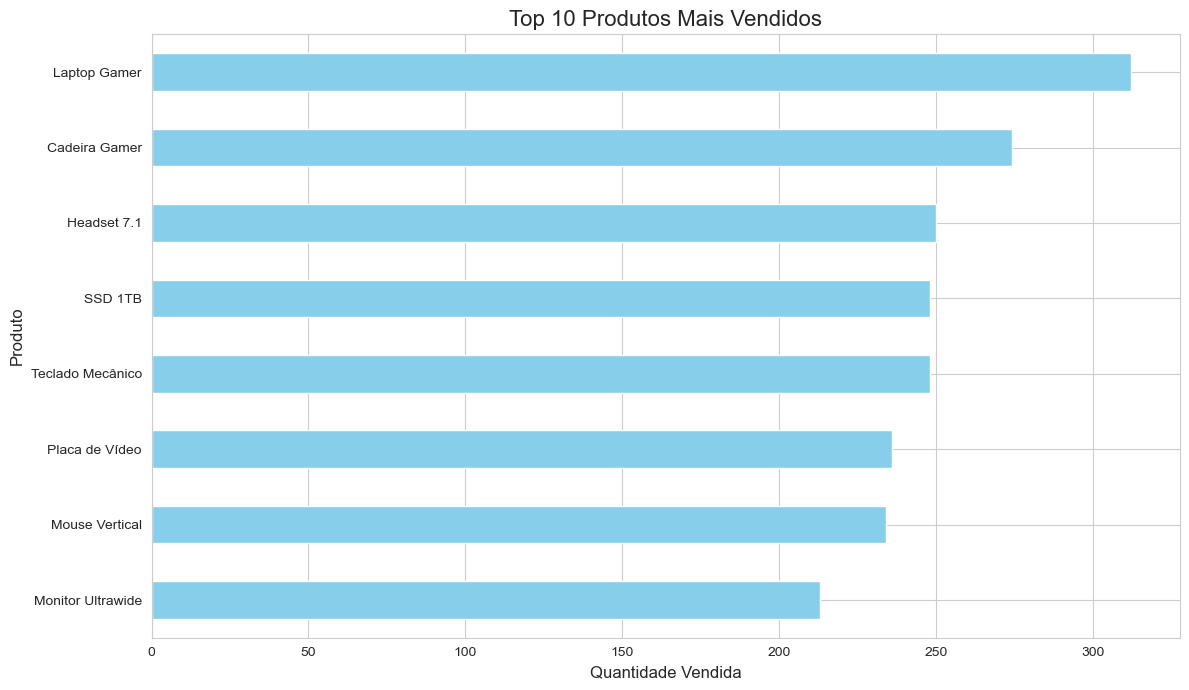

In [22]:
# Define um estilo para os gráficos
sns.set_style("whitegrid")

# Cria a figura e os eixos
plt.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

# Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

In [23]:
df_vendas ['Mes'] = df_vendas['Data_pedido'].dt.to_period('M')

In [24]:
df_vendas.head()

,ID_pedido,Data_pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 03:00:00,Placa de Vídeo,Hardware,4500.00,5,105,Curitiba,PR,22500.00,Normal,2026-01
1,1001,2026-01-01 05:00:00,Laptop Gamer,Eletrônicos,7500.00,3,146,Belo Horizonte,MG,22500.00,Rapida,2026-01
2,1002,2026-01-01 07:00:00,Teclado Mecânico,Acessório,532.33,4,149,Salvador,BA,2129.32,Normal,2026-01
3,1003,2026-01-01 20:00:00,Teclado Mecânico,Acessório,507.23,2,128,Fortaleza,CE,1014.46,Normal,2026-01
4,1004,2026-01-01 12:00:00,Headset 7.1,Acessório,800.00,6,140,Porto Alegre,RS,4800.00,Normal,2026-01


In [25]:
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [26]:
faturamento_mensal

Mes
2026-01    1670092.83
2026-02    1187044.04
2026-03    1628014.90
2026-04     375516.06
Freq: M, Name: Faturamento, dtype: float64

In [27]:
df_vendas.head()

,ID_pedido,Data_pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 03:00:00,Placa de Vídeo,Hardware,4500.00,5,105,Curitiba,PR,22500.00,Normal,2026-01
1,1001,2026-01-01 05:00:00,Laptop Gamer,Eletrônicos,7500.00,3,146,Belo Horizonte,MG,22500.00,Rapida,2026-01
2,1002,2026-01-01 07:00:00,Teclado Mecânico,Acessório,532.33,4,149,Salvador,BA,2129.32,Normal,2026-01
3,1003,2026-01-01 20:00:00,Teclado Mecânico,Acessório,507.23,2,128,Fortaleza,CE,1014.46,Normal,2026-01
4,1004,2026-01-01 12:00:00,Headset 7.1,Acessório,800.00,6,140,Porto Alegre,RS,4800.00,Normal,2026-01


In [28]:
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [29]:
faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,670,092.83
2026-02    R$ 1,187,044.04
2026-03    R$ 1,628,014.90
2026-04      R$ 375,516.06
Name: Faturamento, dtype: object

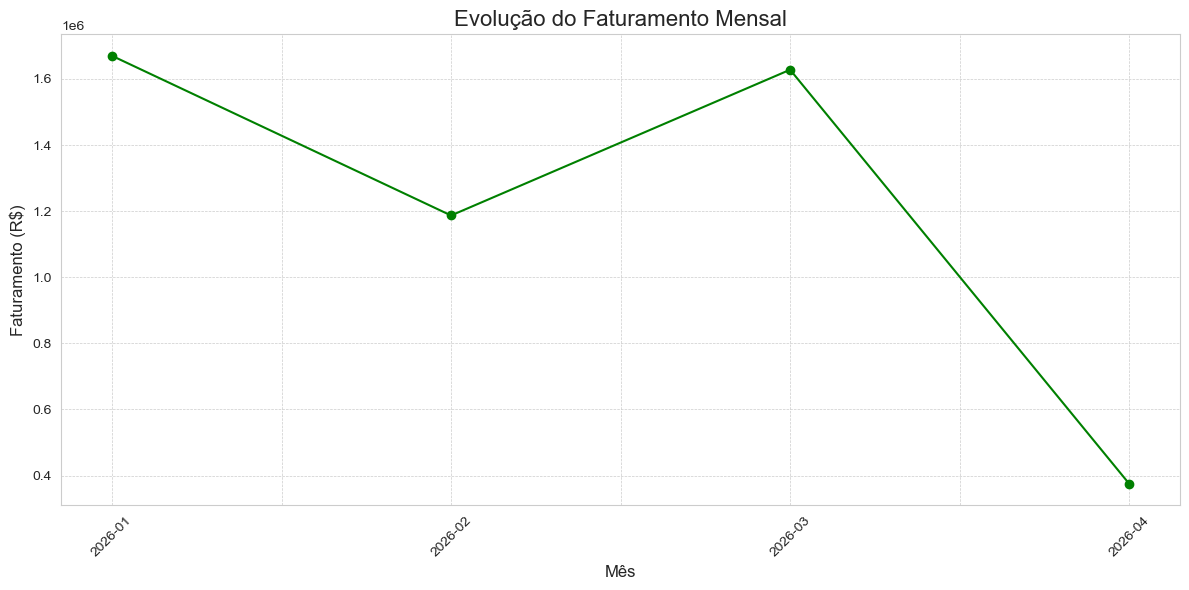

In [30]:
# Cria uma nova figura com tamanho de 12 por 6 polegadas
plt.figure(figsize = (12, 6))

# Plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

# Define o título do gráfico com fonte de tamanho 16
plt.title('Evolução do Faturamento Mensal', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Rotaciona os valores do eixo X em 45 graus para melhor visualização
plt.xticks(rotation = 45)

# Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# Ajusta automaticamente os elementos para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 8. Análise 3 - Vendas Por Estado

Qual o total de vendas por estado?

In [31]:
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [32]:
vendas_estado.map('R${:,.2f}'.format)

Estado
SP    R$932,633.91
MG    R$860,038.02
RS    R$750,538.35
BA    R$614,370.08
CE    R$596,994.74
PR    R$575,632.59
RJ    R$530,460.14
Name: Faturamento, dtype: object

https://seaborn.pydata.org/generated/seaborn.color_palette.html

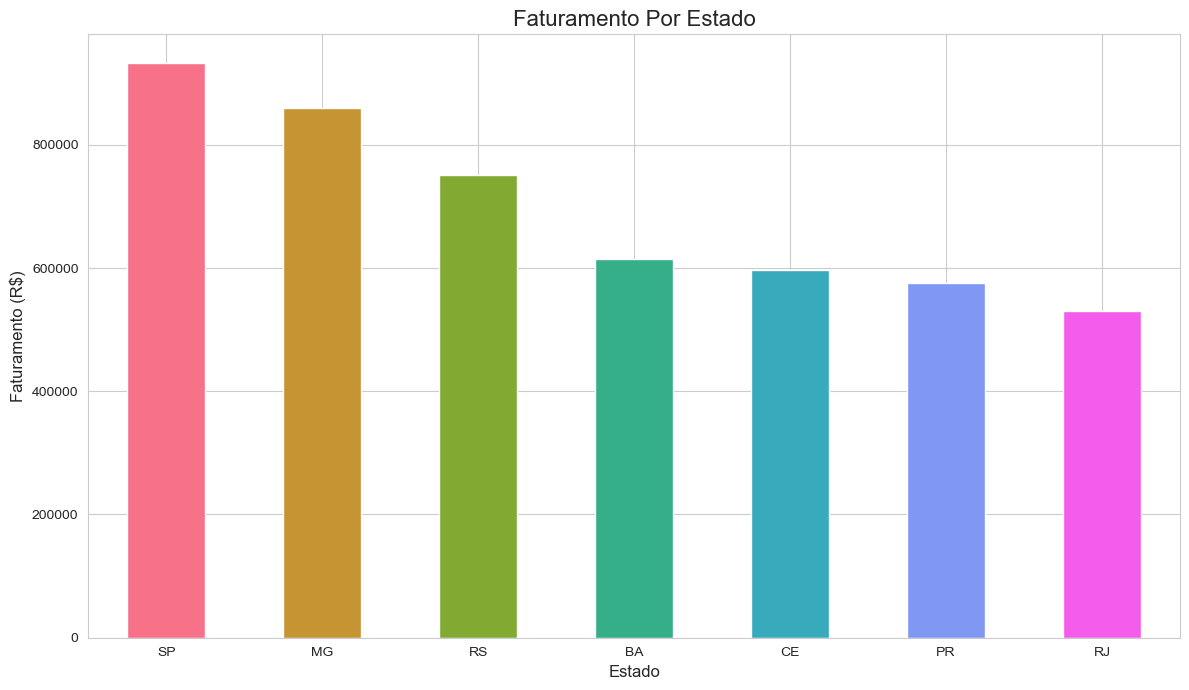

In [33]:
# Cria uma nova figura com tamanho de 12 por 7 polegadas
plt.figure(figsize = (12, 7))

# Plota os dados de faturamento por estado em formato de gráfico de barras
# Usando a paleta de cores "rocket" do Seaborn
vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl", 7))

# Define o título do gráfico com fonte de tamanho 16
plt.title('Faturamento Por Estado', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Estado', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Mantém os rótulos do eixo X na horizontal (sem rotação)
plt.xticks(rotation = 0)

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

#  9.Análise 4 - Faturamento Por Categoria

Qual o faturamento total por categoria?

In [36]:
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [38]:
faturamento_categoria.map('R${:,.2f}'.format)

Categoria
Eletrônicos    R$2,936,400.00
Hardware       R$1,210,800.00
Acessório        R$384,667.83
Móveis           R$328,800.00
Name: Faturamento, dtype: object

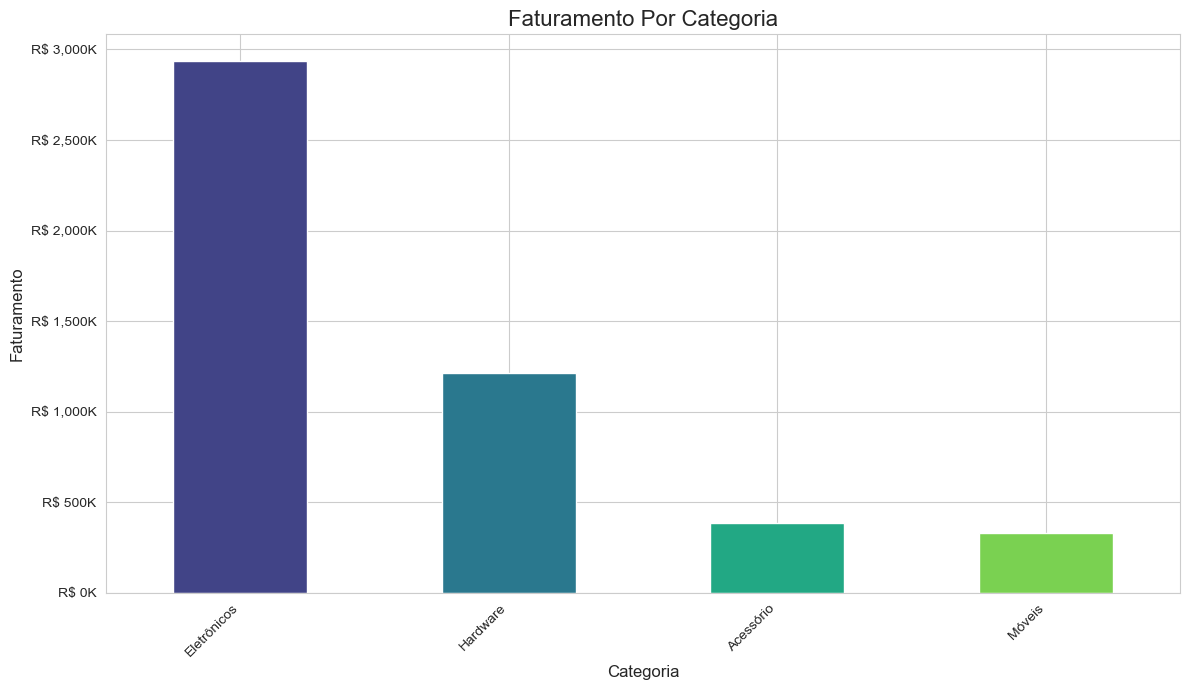

In [39]:
# Importa a função FuncFormatter para formatar os eixos
from matplotlib.ticker import FuncFormatter

# Ordena os dados para o gráfico ficar mais fácil de ler
faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

# Cria a Figura e os Eixos (ax) com plt.subplots()
# Isso nos dá mais controle sobre os elementos do gráfico.
fig, ax = plt.subplots(figsize = (12, 7))

# Cria uma função para formatar os números
# Esta função recebe um valor 'y' e o transforma em uma string no formato 'R$ XX K'
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

# Cria o objeto formatador
formatter = FuncFormatter(formatador_milhares)

# Aplica o formatador ao eixo Y (ax.yaxis)
ax.yaxis.set_major_formatter(formatter)

# Plota os dados usando o objeto 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_ordenado)))

# Adiciona títulos e labels usando 'ax.set_...'
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

# Ajusta a rotação dos rótulos do eixo X
plt.xticks(rotation = 45, ha = 'right')

# Garante que tudo fique bem ajustado na imagem final
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 10. Conclusão e Entrega do Resultado

Existem várias formas de entregar um projeto de análise de dados e a escolha depende do público, do contexto e dos objetivos. Três formas bastante utilizadas são:

**10.1. Relatório técnico ou executivo (PDF, DOCX, etc.)**

Essa forma é clássica e muito útil quando o público precisa de um documento formal para consulta. O relatório pode conter descrição da metodologia, exploração dos dados, gráficos, tabelas e conclusões. É comum separar a linguagem: uma versão mais técnica (com código, estatísticas detalhadas e testes) e outra mais executiva (com foco em insights, recomendações e storytelling de dados).

**10.2. Dashboard interativo (Power BI, Tableau, Looker, Streamlit, Dash, etc.)**

Um dashboard permite que os usuários explorem os dados por conta própria, filtrando informações, ajustando períodos de tempo ou focando em variáveis específicas. Essa forma de entrega é muito valorizada em ambientes corporativos, pois facilita a tomada de decisão contínua e não exige conhecimentos técnicos avançados dos usuários finais.

**10.3. Apresentação (slides em PowerPoint, Google Slides, etc.)**

Ideal para reuniões de stakeholders, a entrega em formato de apresentação resume os principais pontos do projeto. Ela foca nas descobertas mais relevantes, nas implicações para o negócio e nas recomendações práticas, usando gráficos e visualizações impactantes. A ideia é contar a história dos dados de forma clara e direta, evitando sobrecarregar o público com detalhes técnicos.

Confira exemplos práticos em <a href="https://www.datascienceacademy.com.br/course/storytelling-dashboards-e-tecnicas-de-apresentacao-para-cientistas-de-dados">Storytelling, Dashboards e Técnicas de Apresentação Para Cientistas de Dados</a>

# Fim